#📌 Extracción

In [128]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
url = 'https://raw.githubusercontent.com/piposk8/Telecom-X/refs/heads/master/TelecomX_Data.json'
telecom = pd.read_json(url)
telecom.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [18]:
customer_data = telecom['customer'].apply(pd.Series)


In [19]:
phone_data = telecom['phone'].apply(pd.Series)


In [20]:
internet_data = telecom['internet'].apply(pd.Series)



In [21]:
account_data = telecom['account'].apply(pd.Series)
account_data.head()

,Contract,PaperlessBilling,PaymentMethod,Charges
0,One year,Yes,Mailed check,"{'Monthly': 65.6, 'Total': '593.3'}"
1,Month-to-month,No,Mailed check,"{'Monthly': 59.9, 'Total': '542.4'}"
2,Month-to-month,Yes,Electronic check,"{'Monthly': 73.9, 'Total': '280.85'}"
3,Month-to-month,Yes,Electronic check,"{'Monthly': 98.0, 'Total': '1237.85'}"
4,Month-to-month,Yes,Mailed check,"{'Monthly': 83.9, 'Total': '267.4'}"


In [22]:
charges_data = account_data['Charges'].apply(pd.Series)
charges_data.head()

,Monthly,Total
0,65.6,593.3
1,59.9,542.4
2,73.9,280.85
3,98.0,1237.85
4,83.9,267.4


In [23]:
account_data = account_data.drop('Charges', axis=1)


,Contract,PaperlessBilling,PaymentMethod
0,One year,Yes,Mailed check
1,Month-to-month,No,Mailed check
2,Month-to-month,Yes,Electronic check
3,Month-to-month,Yes,Electronic check
4,Month-to-month,Yes,Mailed check


In [24]:
account_data = pd.concat([account_data,charges_data], axis=1)
account_data

,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,One year,Yes,Mailed check,65.60,593.3
1,Month-to-month,No,Mailed check,59.90,542.4
2,Month-to-month,Yes,Electronic check,73.90,280.85
3,Month-to-month,Yes,Electronic check,98.00,1237.85
4,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...
7262,One year,No,Mailed check,55.15,742.9
7263,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,Month-to-month,Yes,Mailed check,50.30,92.75
7265,Two year,No,Mailed check,67.85,4627.65


In [25]:
telecom = pd.concat([telecom, customer_data, phone_data, internet_data, account_data], axis=1)
telecom

,customerID,Churn,customer,phone,internet,account,gender,SeniorCitizen,Partner,Dependents,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '...",Female,0,Yes,Yes,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,0,No,No,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,0,No,No,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,1,Yes,No,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Female,1,Yes,No,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '...",Female,0,No,No,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,0,Yes,No,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,0,No,No,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '...",Male,0,Yes,Yes,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [27]:
telecom = telecom.drop(['customer', 'phone', 'internet', 'account'], axis=1)
telecom

KeyError: "['customer', 'phone', 'internet', 'account'] not found in axis"

In [28]:
telecom

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [30]:
telecom['Total'] = pd.to_numeric(telecom['Total'], errors='coerce')
telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [33]:
print(f"Total de filas duplicadas: {telecom.duplicated().sum()}")

Total de filas duplicadas: 0


In [34]:
ids_dupl= telecom['customerID'].duplicated().sum()
ids_dupl

np.int64(0)

In [35]:
telecom['Total'] = telecom['Total'].fillna(0)


In [36]:
telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [39]:
telecom['Churn'].unique()#listo

array(['No', 'Yes', ''], dtype=object)

In [46]:
telecom['MultipleLines'].unique() #listo

array(['No', 'Yes', 'No phone service'], dtype=object)

In [48]:
telecom['OnlineSecurity'].unique() #listo

array(['No', 'Yes', 'No internet service'], dtype=object)

In [49]:
telecom['OnlineBackup'].unique() #listo

array(['Yes', 'No', 'No internet service'], dtype=object)

In [50]:
telecom['DeviceProtection'].unique() #listo

array(['No', 'Yes', 'No internet service'], dtype=object)

In [51]:
telecom['TechSupport'].unique() #listo

array(['Yes', 'No', 'No internet service'], dtype=object)

In [52]:
telecom['StreamingTV'].unique() #listo

array(['Yes', 'No', 'No internet service'], dtype=object)

In [53]:
telecom['StreamingMovies'].unique() #listo

array(['No', 'Yes', 'No internet service'], dtype=object)

In [59]:
telecom['Churn']=telecom['Churn'].replace('', 'No')
telecom['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [60]:
telecom['MultipleLines'] = telecom['MultipleLines'].replace('No phone service', 'No')
telecom['MultipleLines'].unique()

array(['No', 'Yes'], dtype=object)

In [61]:
telecom['OnlineSecurity'] = telecom['OnlineSecurity'].replace('No internet service', 'No')
telecom['OnlineSecurity'].unique()

array(['No', 'Yes'], dtype=object)

In [62]:
telecom['OnlineBackup'] = telecom['OnlineBackup'].replace('No internet service', 'No')
telecom['OnlineBackup'].unique()

array(['Yes', 'No'], dtype=object)

In [65]:
#telecom['DeviceProtection'] = telecom['DeviceProtection'].replace('No internet service', 'No')
telecom['DeviceProtection'].unique()

array(['No', 'Yes'], dtype=object)

In [66]:
telecom['TechSupport'] = telecom['TechSupport'].replace('No internet service', 'No')
telecom['TechSupport'].unique()

array(['Yes', 'No'], dtype=object)

In [67]:
telecom['StreamingTV'] = telecom['StreamingTV'].replace('No internet service', 'No')
telecom['StreamingTV'].unique()

array(['Yes', 'No'], dtype=object)

In [68]:
telecom['StreamingMovies'] = telecom['StreamingMovies'].replace('No internet service', 'No')
telecom['StreamingMovies'].unique()

array(['No', 'Yes'], dtype=object)

In [73]:
telecom['customerID'].unique()

array(['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', ..., '9992-UJOEL',
       '9993-LHIEB', '9995-HOTOH'], dtype=object)

Ahora que los datos están limpios, es momento de crear la columna "Cuentas_Diarias". Utiliza la facturación mensual para calcular el valor diario, proporcionando una visión más detallada del comportamiento de los clientes a lo largo del tiempo.

In [74]:
telecom['cuentas_diarias'] = telecom['Total'] / telecom['Monthly']
telecom.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total,cuentas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,9.044207
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,9.055092
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,3.800406
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,12.631122
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,3.187128


In [75]:
telecom['Churn']= telecom['Churn'].replace('No', '0')
telecom['Churn']= telecom['Churn'].replace('Yes', '1')
telecom['Churn']= telecom['Churn'].astype(int)
telecom.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total,cuentas_diarias
0,0002-ORFBO,0,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,9.044207
1,0003-MKNFE,0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,9.055092
2,0004-TLHLJ,1,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,3.800406
3,0011-IGKFF,1,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,12.631122
4,0013-EXCHZ,1,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,3.187128


In [76]:
telecom['Partner']= telecom['Partner'].replace('No', '0')
telecom['Partner']= telecom['Partner'].replace('Yes', '1')

In [77]:
telecom['Dependents']= telecom['Dependents'].replace('No', '0')
telecom['Dependents']= telecom['Dependents'].replace('Yes', '1')

In [78]:
telecom['PhoneService']= telecom['PhoneService'].replace('No', '0')
telecom['PhoneService']= telecom['PhoneService'].replace('Yes', '1')

In [79]:
telecom['MultipleLines'] = telecom['MultipleLines'].replace('No', '0')
telecom['MultipleLines'] = telecom['MultipleLines'].replace('Yes', '1')


In [80]:
telecom['DeviceProtection'] = telecom['DeviceProtection'].replace('No', '0')
telecom['DeviceProtection'] = telecom['DeviceProtection'].replace('No', '1')

In [81]:
telecom['TechSupport'] = telecom['TechSupport'].replace('No', '0')
telecom['TechSupport'] = telecom['TechSupport'].replace('Yes', '1')

In [82]:
telecom['StreamingTV'] = telecom['StreamingTV'].replace('No', '0')
telecom['StreamingTV'] = telecom['StreamingTV'].replace('Yes', '1')

In [83]:
telecom['StreamingMovies'] = telecom['StreamingMovies'].replace('No', '0')
telecom['StreamingMovies'] = telecom['StreamingMovies'].replace('No','1')

In [84]:
telecom['PaperlessBilling'] = telecom['PaperlessBilling'].replace('No', '0')
telecom['PaperlessBilling'] = telecom['PaperlessBilling'].replace('Yes', '1')


In [85]:
telecom

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total,cuentas_diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.60,593.30,9.044207
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,Yes,Month-to-month,0,Mailed check,59.90,542.40,9.055092
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,Yes,0,0,0,Month-to-month,1,Electronic check,73.90,280.85,3.800406
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,Yes,0,1,Yes,Month-to-month,1,Electronic check,98.00,1237.85,12.631122
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40,3.187128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,0,Female,0,0,0,13,1,0,DSL,...,0,1,0,0,One year,0,Mailed check,55.15,742.90,13.470535
7263,9992-RRAMN,1,Male,0,1,0,22,1,1,Fiber optic,...,0,0,0,Yes,Month-to-month,1,Electronic check,85.10,1873.70,22.017626
7264,9992-UJOEL,0,Male,0,0,0,2,1,0,DSL,...,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75,1.843936
7265,9993-LHIEB,0,Male,0,1,1,67,1,0,DSL,...,Yes,1,0,Yes,Two year,0,Mailed check,67.85,4627.65,68.204127


In [87]:
telecom['Partner']= telecom['Partner'].astype(int)
telecom['Dependents']= telecom['Dependents'].astype(int)
telecom['PhoneService']= telecom['PhoneService'].astype(int)
telecom['MultipleLines'] = telecom['MultipleLines'].astype(int)
telecom['DeviceProtection'] = telecom['DeviceProtection'].astype(int)
telecom['TechSupport'] = telecom['TechSupport'].astype(int)
telecom['StreamingTV'] = telecom['StreamingTV'].astype(int)
telecom['StreamingMovies'] = telecom['StreamingMovies'].astype(int)
telecom['PaperlessBilling'] = telecom['PaperlessBilling'].astype(int)


ValueError: invalid literal for int() with base 10: 'Yes'

In [88]:
telecom['Partner']= telecom['Partner'].astype(int)

In [89]:
telecom['Dependents']= telecom['Dependents'].astype(int)

In [90]:
telecom['PhoneService']= telecom['PhoneService'].astype(int)

In [91]:
telecom['MultipleLines'] = telecom['MultipleLines'].astype(int)

In [96]:
telecom['DeviceProtection'] = telecom['DeviceProtection'].astype(int)

In [95]:
telecom['DeviceProtection']= telecom['DeviceProtection'].replace('Yes', '1')
telecom['DeviceProtection'].unique()

array(['0', '1'], dtype=object)

In [97]:
telecom['TechSupport'] = telecom['TechSupport'].astype(int)

In [98]:
telecom['StreamingTV'] = telecom['StreamingTV'].astype(int)

In [100]:
telecom['StreamingMovies'] = telecom['StreamingMovies'].replace('Yes', '1')
telecom['StreamingMovies'].unique()

array(['0', '1'], dtype=object)

In [101]:
telecom['PaperlessBilling'] = telecom['PaperlessBilling'].astype(int)

In [105]:
telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   int64  
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   int64  
 5   Dependents        7267 non-null   int64  
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   int64  
 8   MultipleLines     7267 non-null   int64  
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   int64  
 13  TechSupport       7267 non-null   int64  
 14  StreamingTV       7267 non-null   int64  
 15  StreamingMovies   7267 non-null   int64  
 16  Contract          7267 non-null   object 


In [103]:
telecom['StreamingMovies'] = telecom['StreamingMovies'].astype(int)

In [106]:
columnas_espanol = {
    'customerID': 'ID_Cliente',
    'Churn': 'Cancelado',
    'gender': 'Genero',
    'SeniorCitizen': 'Adulto_Mayor',
    'Partner': 'En_Pareja',
    'Dependents': 'Personas_a_Cargo',
    'tenure': 'Meses_Permanencia',
    'PhoneService': 'Servicio_Telefonico',
    'MultipleLines': 'Multiples_Lineas',
    'InternetService': 'Tipo_Internet',
    'OnlineSecurity': 'Seguridad_Online',
    'OnlineBackup': 'Respaldo_Nube',
    'DeviceProtection': 'Proteccion_Dispositivo',
    'TechSupport': 'Soporte_Tecnico',
    'StreamingTV': 'TV_Streaming',
    'StreamingMovies': 'Peliculas_Streaming',
    'Contract': 'Tipo_Contrato',
    'PaperlessBilling': 'Factura_Digital',
    'PaymentMethod': 'Metodo_Pago',
    'Monthly': 'Cargo_Mensual',
    'Total': 'Cargo_Total'
}

telecom=telecom.rename(columns=columnas_espanol)

In [107]:
telecom

,ID_Cliente,Cancelado,Genero,Adulto_Mayor,En_Pareja,Personas_a_Cargo,Meses_Permanencia,Servicio_Telefonico,Multiples_Lineas,Tipo_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,TV_Streaming,Peliculas_Streaming,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargo_Mensual,Cargo_Total,cuentas_diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.60,593.30,9.044207
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40,9.055092
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85,3.800406
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85,12.631122
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40,3.187128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,0,Female,0,0,0,13,1,0,DSL,...,0,1,0,0,One year,0,Mailed check,55.15,742.90,13.470535
7263,9992-RRAMN,1,Male,0,1,0,22,1,1,Fiber optic,...,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70,22.017626
7264,9992-UJOEL,0,Male,0,0,0,2,1,0,DSL,...,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75,1.843936
7265,9993-LHIEB,0,Male,0,1,1,67,1,0,DSL,...,1,1,0,1,Two year,0,Mailed check,67.85,4627.65,68.204127


📊 Carga y análisis

In [126]:
#consumo
cols_numericas = ['Meses_Permanencia', 'Cargo_Mensual', 'Cargo_Total']
resumen_num = telecom[cols_numericas].describe().T
resumen_num['mediana'] = telecom[cols_numericas].median()
print(resumen_num[['mean', 'mediana', 'std', 'min', 'max']].round(2))

                      mean  mediana      std    min      max
Meses_Permanencia    32.35     29.0    24.57   0.00    72.00
Cargo_Mensual        64.72     70.3    30.13  18.25   118.75
Cargo_Total        2277.18   1389.2  2268.65   0.00  8684.80


In [125]:
#porcentaje de perfil de cliente
cols_binarias = ['Cancelado', 'Adulto_Mayor', 'En_Pareja', 'Personas_a_Cargo', 'Servicio_Telefonico']
print((telecom[cols_binarias].mean() * 100).round(2))

Cancelado              25.72
Adulto_Mayor           16.27
En_Pareja              48.41
Personas_a_Cargo       30.01
Servicio_Telefonico    90.27
dtype: float64


In [124]:
#distribucion por tipo de contrato
print((telecom['Tipo_Contrato'].value_counts(normalize=True) * 100).round(2))

#Distribución por Método de Pago
print((telecom['Metodo_Pago'].value_counts(normalize=True) * 100).round(2))

Tipo_Contrato
Month-to-month    55.11
Two year          23.99
One year          20.90
Name: proportion, dtype: float64
Metodo_Pago
Electronic check             33.65
Mailed check                 22.91
Bank transfer (automatic)    21.87
Credit card (automatic)      21.58
Name: proportion, dtype: float64


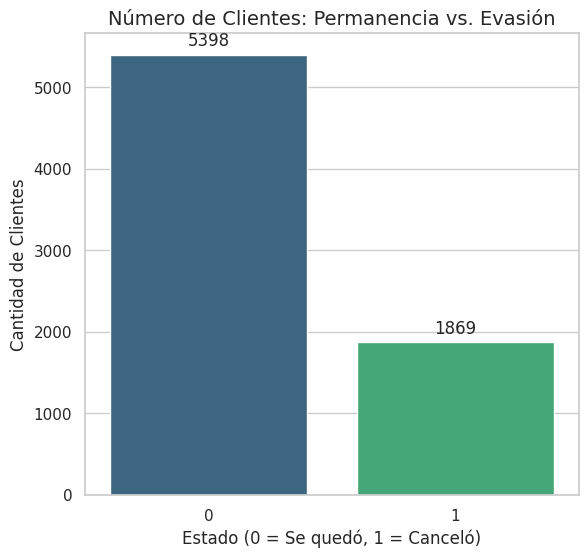

In [134]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

#Frecuencia Absoluta
plt.subplot(1, 2, 1)
ax = sns.countplot(x='Cancelado', data=telecom, hue='Cancelado', palette='viridis', legend=False)
plt.title('Número de Clientes: Permanencia vs. Evasión', fontsize=14)
plt.xlabel('Estado (0 = Se quedó, 1 = Canceló)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)


for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')


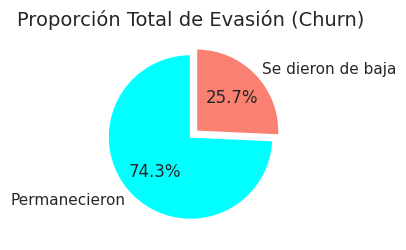

In [140]:
#Proporción Porcentual
plt.subplot(1, 2, 2)
datos_pastel = telecom['Cancelado'].value_counts()
plt.pie(datos_pastel,
        labels=['Permanecieron', 'Se dieron de baja'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['cyan', 'salmon'],
        explode=(0, 0.1)) # Esto separa un poco la rebanada de "Evasión"
plt.title('Proporción Total de Evasión (Churn)', fontsize=14)

plt.tight_layout()
plt.show()

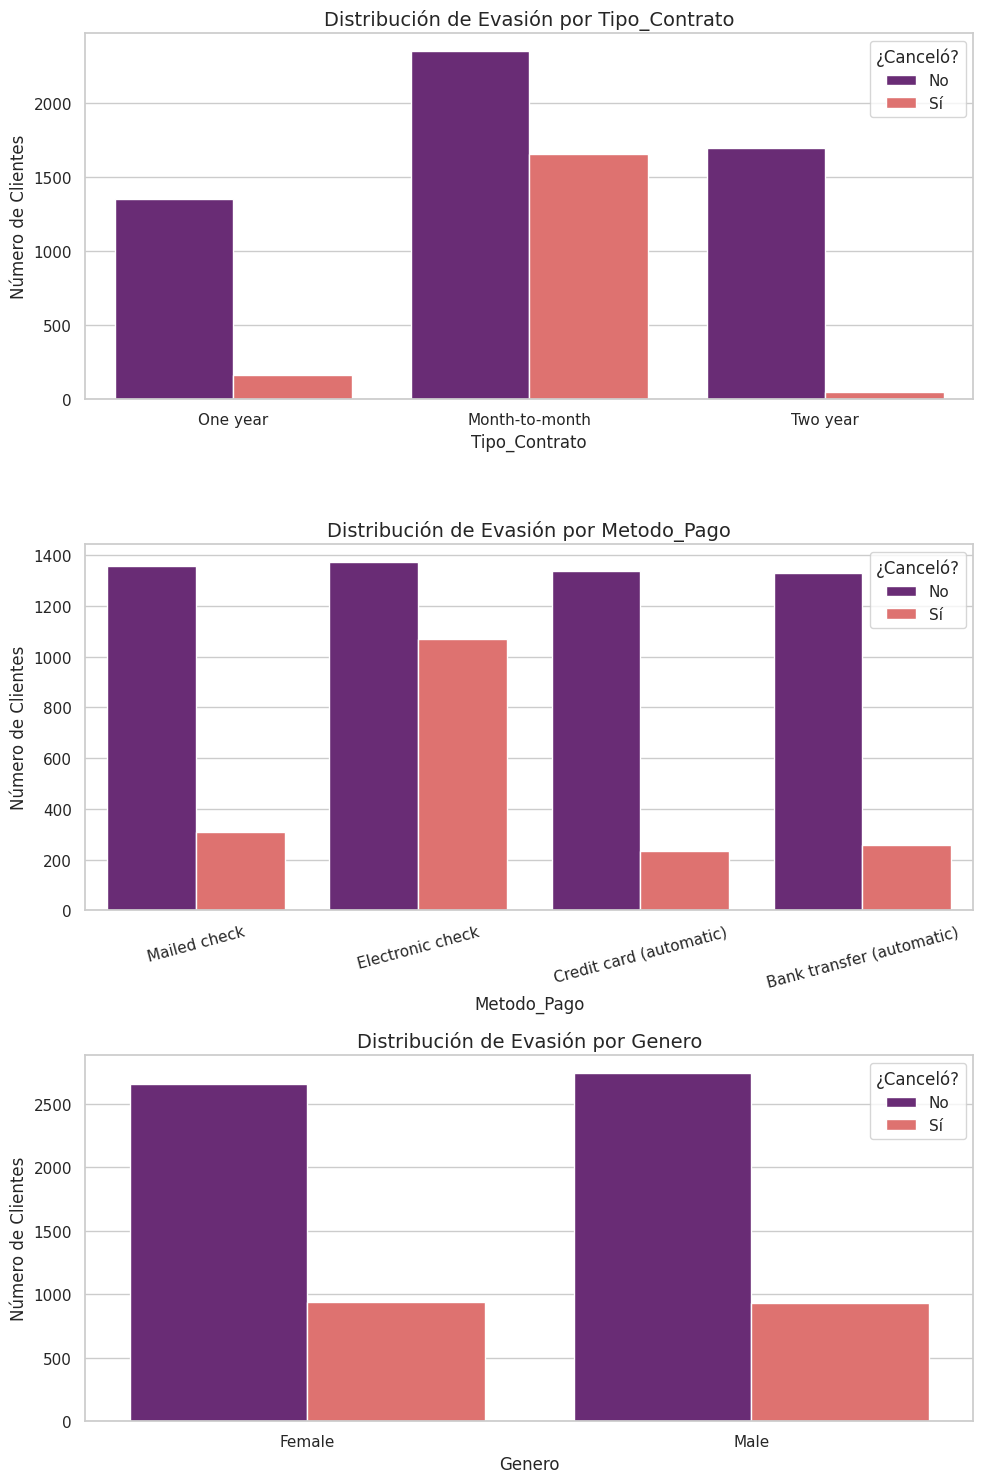

In [141]:

variables = ['Tipo_Contrato', 'Metodo_Pago', 'Genero']
fig, axes = plt.subplots(len(variables), 1, figsize=(10, 15))

for i, var in enumerate(variables):
    sns.countplot(x=var, hue='Cancelado', data=telecom, palette='magma', ax=axes[i])
    axes[i].set_title(f'Distribución de Evasión por {var}', fontsize=14)
    axes[i].set_xlabel(var, fontsize=12)
    axes[i].set_ylabel('Número de Clientes', fontsize=12)
    axes[i].legend(title='¿Canceló?', labels=['No', 'Sí'])
    if var == 'Metodo_Pago':
        axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [145]:
reporte_contrato = (telecom.groupby('Tipo_Contrato')['Cancelado'].mean() * 100).round(2).reset_index()
reporte_contrato.columns = ['Tipo de Contrato', '% de Probabilidad de Abandono']

reporte_contrato = reporte_contrato.sort_values(by='% de Probabilidad de Abandono', ascending=False)

print(reporte_contrato.to_string(index=False))

Tipo de Contrato  % de Probabilidad de Abandono
  Month-to-month                          41.32
        One year                          10.93
        Two year                           2.75


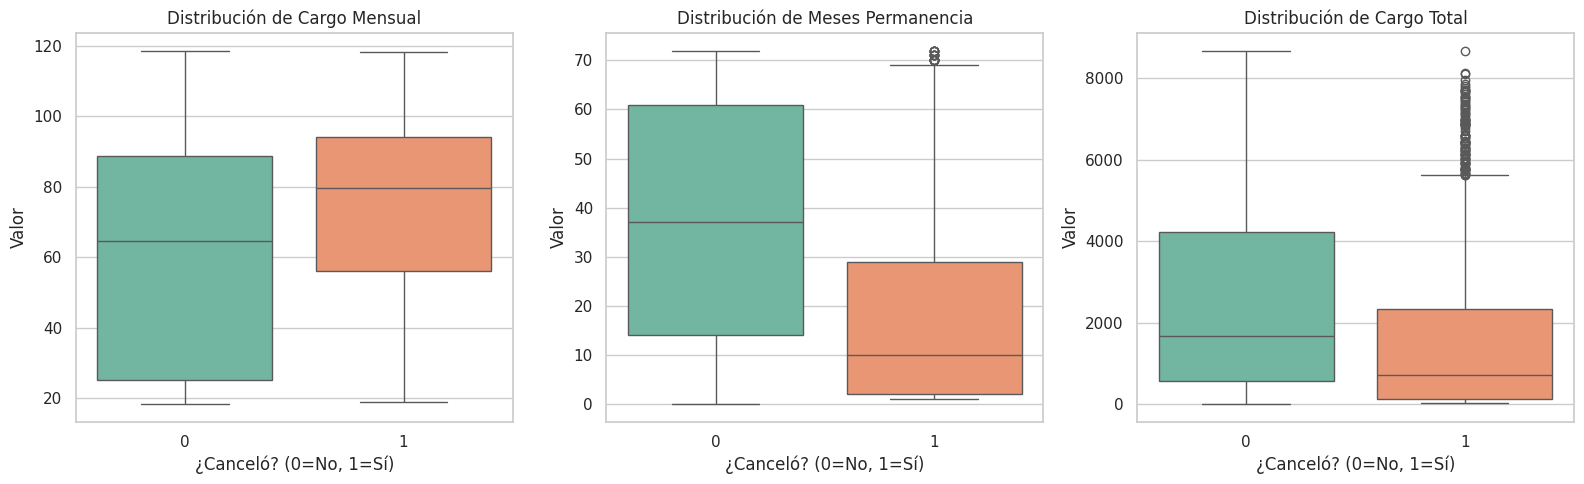

In [147]:
vars_numericas = ['Cargo_Mensual', 'Meses_Permanencia', 'Cargo_Total']

plt.figure(figsize=(16, 5))

for i, var in enumerate(vars_numericas):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='Cancelado', y=var, data=telecom, palette='Set2', hue='Cancelado', legend=False)
    plt.title(f'Distribución de {var.replace("_", " ")}')
    plt.xlabel('¿Canceló? (0=No, 1=Sí)')
    plt.ylabel('Valor')

plt.tight_layout()
plt.show()

/tmp/ipykernel_271/1063985128.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=telecom, x='Cargo_Mensual', hue='Cancelado', shade=True, palette='husl')


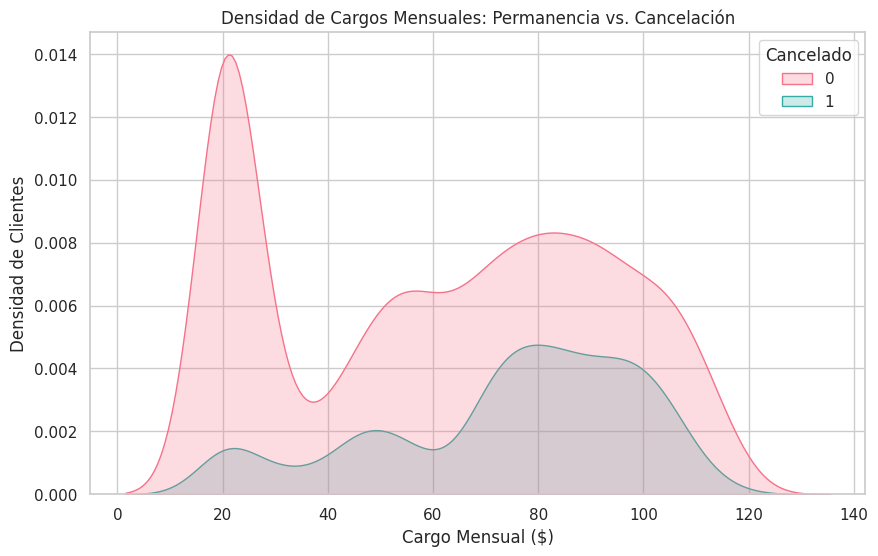

In [148]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=telecom, x='Cargo_Mensual', hue='Cancelado', shade=True, palette='husl')
plt.title('Densidad de Cargos Mensuales: Permanencia vs. Cancelación')
plt.xlabel('Cargo Mensual ($)')
plt.ylabel('Densidad de Clientes')
plt.show()

Introducción

El objetivo de este análisis es identificar los factores que influyen en la evasión de clientes de la compañía de telecomunicaciones.

El "Churn" representa la pérdida de suscriptores, lo cual impacta directamente en los ingresos y la estabilidad del negocio.

A través de este estudio, buscamos patrones que nos permitan predecir y prevenir que los clientes cancelen su servicio.



#Limpieza de datos
Para asegurar la calidad del analisis se hizo la limpeiza de datos detallada de algunas de las columnas importantes para poder realizar los analisis conrrespondientes.

se hizo la importacion de los datos y se cambiaron ciertas columnas con tipografia que se pudiera cambiqar a 1 y 0 para poder cuantificar ciertos requerimientos para analizar, se cambiaron tipografias de forma que se traducieron al español para tener en claro que columna se manipularia.



# Análisis Exploratorio de Datos

Distribución de Aproximadamente el 26.5% de la base de clientes ha cancelado el servicio, lo que representa un desafío significativo para la retención.

Impacto de los clientes con contratos Mes a Mes tienen una probabilidad de abandono del 41.32%, mientras que los de contratos a largo plazo 2 años apenas llegan al 2.75%.

Análisis de Cargos: El gráfico de densidad reveló que los clientes con facturas mensuales altas entre 70 y 100 tienden a irse con más frecuencia que aquellos con servicios básicos.

#Conclusiones

### El contrato es el predictor mas grande el cual se identifica con el compromiso a corto plazo por que el cliente puede cancelarlo pronto, la falta de un contrato anual facilita que el cleinte se vaya ante cualquuier oferta de la competencia.
###Sensibilidad al Precio: Los servicios "Premium" o más costosos muestran una tasa de deserción mayor, sugiriendo que el valor percibido podría no estar alineado con el precio en esos rangos.
###Vulnerabilidad Inicial: Los nuevos clientes son los más propensos a la evasión, lo que indica una posible falla en la experiencia

# Recomendaciones Estratégicas
### una de las eestrategias pued ser la de incentivar a los clientes con promociones de descuentos para contratos anuales, ademas de hacer promociones para los primeros 6 meses como bonos o atencion prioritaria y una de las importantes dado que los pagos son manuales al momenot de domicilar alguna tarjeta de credito se puede dart algun porcentaje de descuento.